# Home assignment #2

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Загрузка данных

In [2]:
df_gps = pd.read_csv("Location.csv")
df_acc = pd.read_csv("Accelerometer.csv")

# Переименование колонок для удобства
df_gps.columns = ['time', 'lat', 'lon', 'height', 'vel', 'dir', 'h_acc', 'v_acc']
df_acc.columns = ['time', 'ax', 'ay', 'az']

# Удаляем строки с пропущенными координатами GPS
df_gps = df_gps.dropna(subset=['lat', 'lon']).reset_index(drop=True)

## Расчёт дистанции по GPS (Haversine)

In [3]:
R = 6378137  # радиус Земли в метрах
lat0 = df_gps.lat.iloc[0]
lon0 = df_gps.lon.iloc[0]

# Проекция на плоскость 
df_gps['x'] = R * np.radians(df_gps.lon - lon0) * np.cos(np.radians(lat0))
df_gps['y'] = R * np.radians(df_gps.lat - lat0)

# Смещение от старта – для фильтра как измерение z
df_gps['dist_from_start'] = np.sqrt(df_gps.x**2 + df_gps.y**2)

# Пройденный путь по GPS
gps_path = [0]
for i in range(1, len(df_gps)):
    step = np.sqrt((df_gps.x.iloc[i] - df_gps.x.iloc[i-1])**2 + (df_gps.y.iloc[i] - df_gps.y.iloc[i-1])**2)
    gps_path.append(gps_path[-1] + step)
df_gps['path'] = gps_path

## Оценка параметров шума

In [4]:
# Участок относительного покоя(не было возможности положить телефон на пол)
acc_static = df_acc[df_acc.time <= 10]
if len(acc_static) > 10:
    # Оценка смещения акселерометра по оси X 
    bias = acc_static.ax.mean()
    df_acc['ax_lin'] = df_acc.ax - bias
    # Шум процесса (std_acc) – стандартное отклонение акселерометра в покое
    std_acc = np.std(acc_static.ax - bias)
else:
    df_acc['ax_lin'] = df_acc.ax
    std_acc = 0.5

# Шум измерения (std_meas) – стандартное отклонение GPS на участке покоя
if len(df_gps[df_gps.time <= 5]) > 1:
    std_meas = np.std(df_gps[df_gps.time <= 5].dist_from_start)
else:
    std_meas = 3.0  

print(f"Оценка std_acc: {std_acc:.4f} м/с²")
print(f"Оценка std_meas: {std_meas:.2f} м")

Оценка std_acc: 0.5954 м/с²
Оценка std_meas: 9.73 м


## Реализация фильтра Калмана

In [5]:
class KalmanFilter:
    def __init__(self, std_acc, std_meas):
        self.x = np.array([[0.0], [0.0]])   
        self.P = np.eye(2) * 5
        self.std_acc = std_acc * 3
        self.std_meas = std_meas

    def predict(self, u, dt):
        A = np.array([[1, dt],
                      [0, 1]])
        B = np.array([[0.5 * dt**2],
                      [dt]])
        Q = np.array([[dt**4/4, dt**3/2],
                      [dt**3/2, dt**2]]) * self.std_acc**2

        self.x = A @ self.x + B * u
        self.P = A @ self.P @ A.T + Q

    def update(self, z):
        H = np.array([[1, 0]])
        R = np.array([[self.std_meas**2]])
        y = np.array([[z]]) - H @ self.x
        S = H @ self.P @ H.T + R
        K = self.P @ H.T @ np.linalg.inv(S)
        self.x = self.x + K @ y
        self.P = (np.eye(2) - K @ H) @ self.P

## Подготовка данных для фильтра

In [6]:
t = df_acc.time.values
u = df_acc.ax_lin.values

# Разности времени (dt)
dt = np.diff(t, prepend=t[0])
dt[0] = np.mean(dt[1:10])  # для первого шага берём среднее

# Интерполируем измерение GPS на времена акселерометра
gps_interp = np.interp(t, df_gps.time, df_gps.dist_from_start)

# Запуск фильтра
kf = KalmanFilter(std_acc, std_meas)
pos_kf = []
vel_kf = []

for i in range(len(t)):
    kf.predict(u[i], dt[i])
    kf.update(gps_interp[i])
    
    if abs(kf.x[1, 0]) < 0.05:
        kf.x[1, 0] = 0
        
    pos_kf.append(kf.x[0, 0])
    vel_kf.append(kf.x[1, 0])

pos_kf = np.array(pos_kf)

## Вычисление пройденного пути по оценкам фильтра

In [7]:
kf_path = np.zeros(len(pos_kf))
for i in range(1, len(pos_kf)):
    kf_path[i] = kf_path[i-1] + abs(pos_kf[i] - pos_kf[i-1])

gps_path_interp = np.interp(t, df_gps.time, df_gps.path)

## Построение графика пройденного пути

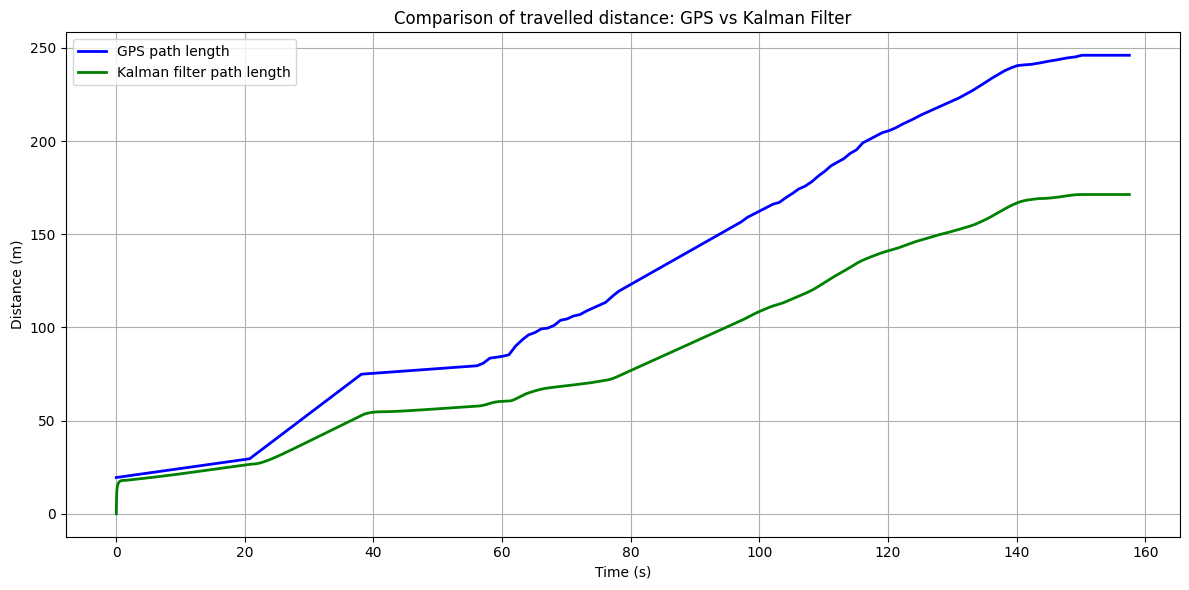

In [8]:
plt.figure(figsize=(12, 6))
plt.plot(t, gps_path_interp, 'b-', linewidth=2, label='GPS path length')
plt.plot(t, kf_path, 'g-', linewidth=2, label='Kalman filter path length')
plt.xlabel('Time (s)')
plt.ylabel('Distance (m)')
plt.title('Comparison of travelled distance: GPS vs Kalman Filter')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Сначала я стоял на месте примерно 10 секунд, затем прошёл около 150–160 метров от остановки до ларька, и в конце снова постоял 10–15 секунд. В результате были получены два графика. Накопленный путь, рассчитанный по GPS, оказался заметно завышен — это связано с дрожанием координат, которое добавляет несколько лишних метров к реальной дистанции. На графике ускорения видно, что фильтр Калмана эффективно сглаживает этот шум, объединяя данные акселерометра и GPS. Темпы движения выглядят вполне логично, однако абсолютное значение пути не всегда вычисляется абсолютно точно.